# 01 — Feature Engineering

Load synthetic CERT telemetry, run the feature pipeline, and inspect the aggregated user-level feature matrix.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
from src.feature_engineering import (
    build_temporal_features,
    build_activity_features,
    build_deviation_features,
    aggregate_user_features,
)

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv('../data/synthetic_cert.csv', parse_dates=['date'])
print(f'Raw shape: {df.shape}')
print(f'Users: {df.user_id.nunique()}, Days: {df.date.nunique()}')
print(f'Label distribution:\n{df.label.value_counts(normalize=True).to_string()}')

Raw shape: (180000, 12)
Users: 2000, Days: 90
Label distribution:
label
0    0.95
1    0.05


In [3]:
features = aggregate_user_features(df)
print(f'Feature matrix shape: {features.shape}')
print(f'Total feature columns (excl user_id, label): {features.shape[1] - 2}')

Feature matrix shape: (2000, 54)
Total feature columns (excl user_id, label): 52


In [4]:
features.head()

,user_id,days_active,after_hours_ratio,weekend_ratio,login_hour_mean,login_hour_variance,usb_event_total,external_email_ratio_mean,failed_login_total,usb_event_spike,...,failed_login_mean,failed_login_max,failed_login_ratio,vpn_usage_ratio,vpn_usage_total,usb_after_hours_total,email_after_hours_total,high_risk_day_count,avg_risk_flags,label
0,USER_0000,90,0.122222,0.277778,10.155556,9.930587,32,0.200278,56,1,...,0.622222,19,0.066667,0.177778,16,32,233,5,0.477778,1
1,USER_0001,90,0.611111,0.277778,6.777778,17.118602,53,0.192022,98,1,...,1.088889,25,0.188889,0.066667,6,50,2106,6,0.888889,1
2,USER_0002,90,0.466667,0.277778,7.000000,8.404494,17,0.178311,7,1,...,0.077778,7,0.011111,0.033333,3,17,398,2,0.577778,1
3,USER_0003,90,0.055556,0.277778,13.100000,5.933708,31,0.205822,52,1,...,0.577778,10,0.111111,0.200000,18,22,40,6,0.466667,1
4,USER_0004,90,0.111111,0.277778,9.966667,8.144944,19,0.160189,40,1,...,0.444444,14,0.088889,0.177778,16,15,130,2,0.444444,1


In [5]:
features.describe().round(3)

,days_active,after_hours_ratio,weekend_ratio,login_hour_mean,login_hour_variance,usb_event_total,external_email_ratio_mean,failed_login_total,usb_event_spike,email_volume_spike,...,failed_login_mean,failed_login_max,failed_login_ratio,vpn_usage_ratio,vpn_usage_total,usb_after_hours_total,email_after_hours_total,high_risk_day_count,avg_risk_flags,label
count,2000.0,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,...,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000
mean,90.0,0.254,0.278,9.119,9.874,38.572,0.184,42.329,0.994,0.994,...,0.470,14.996,0.103,0.194,17.440,22.786,407.170,3.646,0.587,0.990
std,0.0,0.207,0.000,1.814,3.601,24.332,0.017,22.289,0.077,0.077,...,0.248,7.185,0.054,0.138,12.424,15.307,482.683,1.605,0.252,0.097
min,90.0,0.000,0.278,5.311,2.630,0.000,0.128,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.056,0.000
25%,90.0,0.078,0.278,7.789,7.249,22.000,0.172,26.000,1.000,1.000,...,0.289,10.000,0.067,0.089,8.000,11.000,101.750,3.000,0.389,1.000
50%,90.0,0.189,0.278,9.056,9.330,34.000,0.184,40.000,1.000,1.000,...,0.444,14.000,0.089,0.156,14.000,20.000,241.000,4.000,0.544,1.000
75%,90.0,0.378,0.278,10.336,11.937,50.000,0.195,56.000,1.000,1.000,...,0.622,19.000,0.133,0.267,24.000,31.000,539.000,5.000,0.756,1.000
max,90.0,0.811,0.278,16.211,27.044,195.000,0.253,140.000,1.000,1.000,...,1.556,54.000,0.322,0.811,73.000,103.000,6802.000,10.000,1.556,1.000


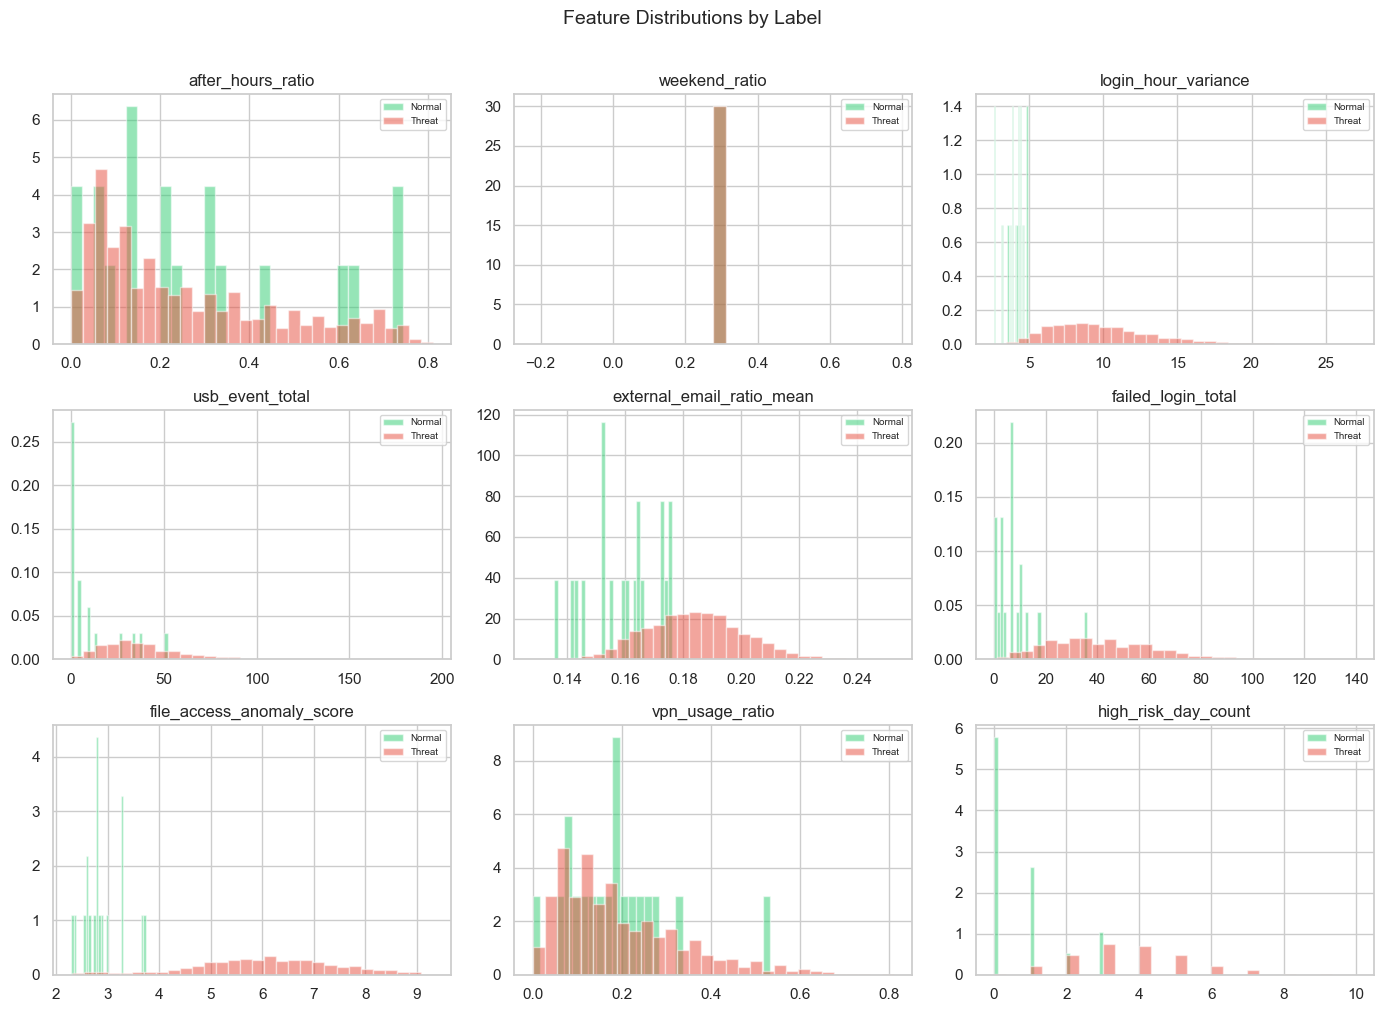

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flat
cols_to_plot = [
    'after_hours_ratio', 'weekend_ratio', 'login_hour_variance',
    'usb_event_total', 'external_email_ratio_mean', 'failed_login_total',
    'file_access_anomaly_score', 'vpn_usage_ratio', 'high_risk_day_count'
]
for ax, col in zip(axes, cols_to_plot):
    for lbl, lbl_name, color in [(0, 'Normal', '#2ecc71'), (1, 'Threat', '#e74c3c')]:
        subset = features[features.label == lbl][col]
        ax.hist(subset, bins=30, alpha=0.5, label=lbl_name, color=color, density=True)
    ax.set_title(col)
    ax.legend(fontsize=7)
fig.suptitle('Feature Distributions by Label', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

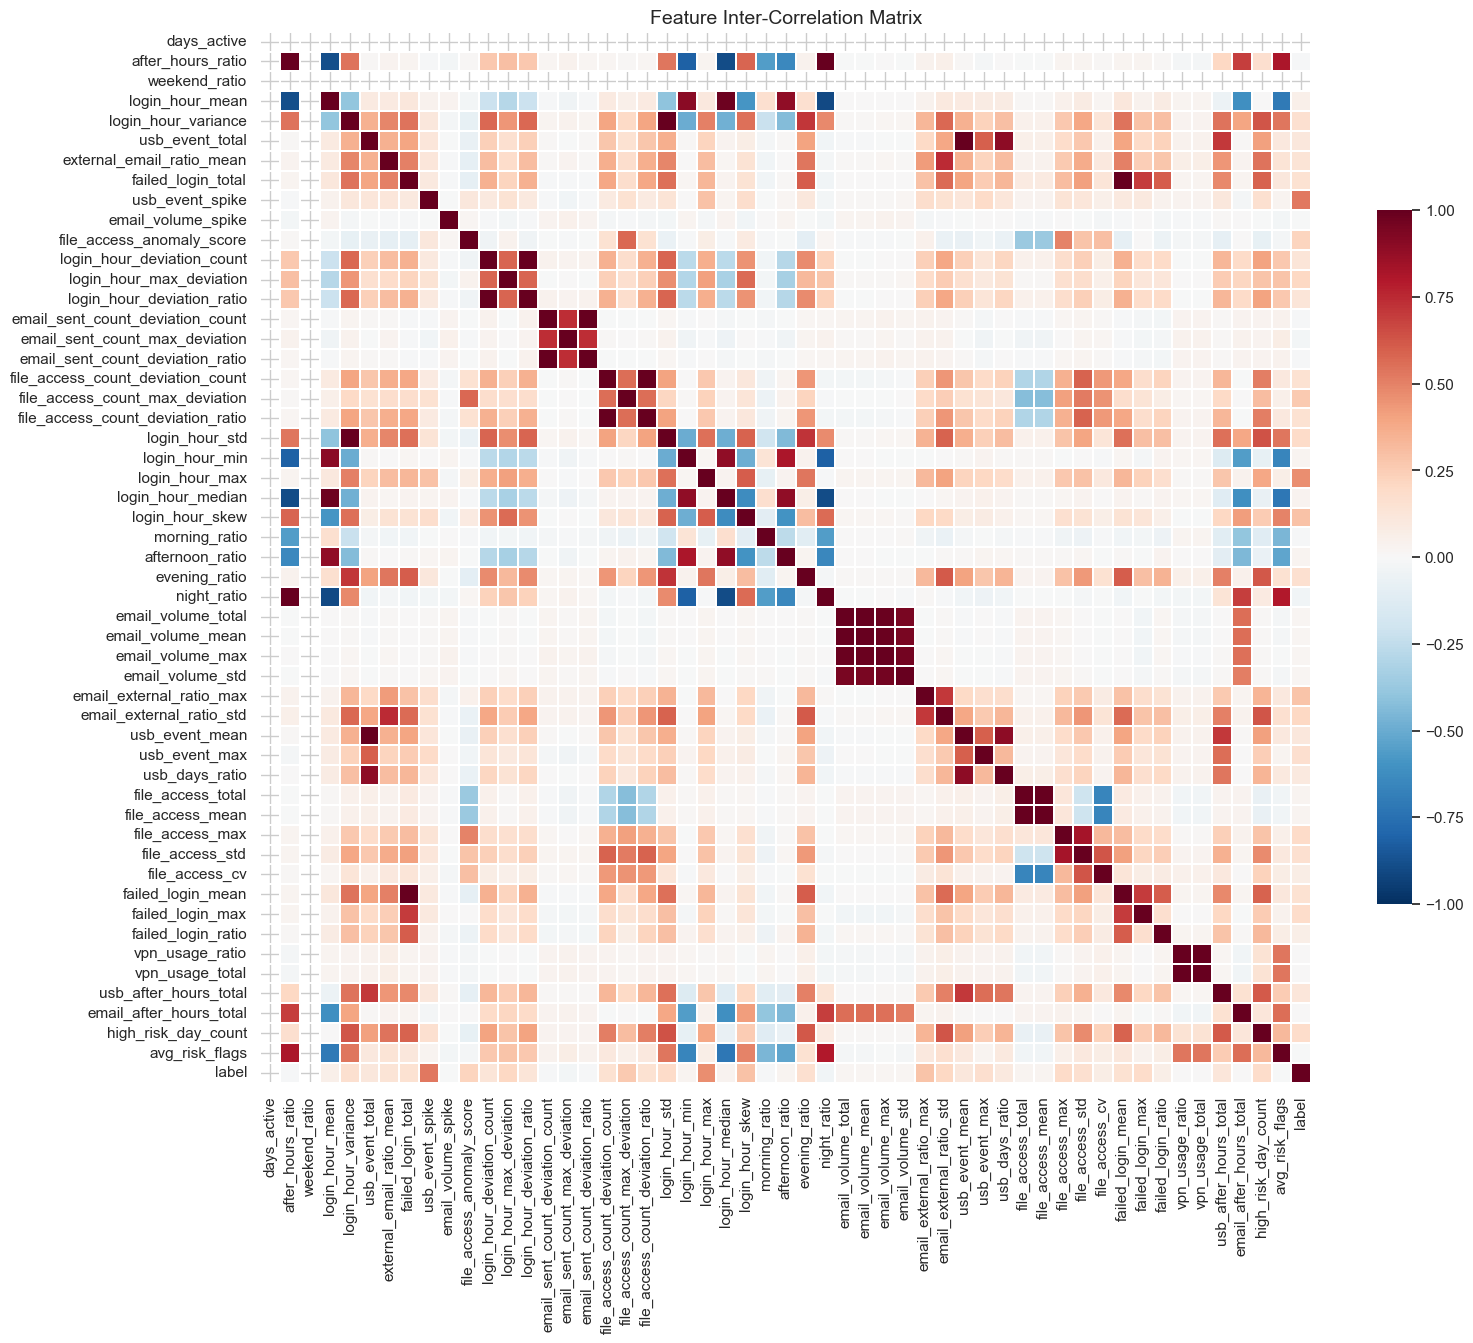

In [7]:
corr = features.drop(columns=['user_id']).corr()
plt.figure(figsize=(16, 14))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.1, cbar_kws={'shrink': 0.6})
plt.title('Feature Inter-Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
feat_cols = [c for c in features.columns if c not in ('user_id', 'label')]
corr_with_label = features[feat_cols + ['label']].corr()['label'].drop('label').abs().sort_values(ascending=False)
print('Top 15 features by |correlation| with label:')
print(corr_with_label.head(15).to_string())

Top 15 features by |correlation| with label:
usb_event_spike                    0.526343
login_hour_max                     0.466465
login_hour_skew                    0.292014
email_external_ratio_max           0.283902
file_access_count_max_deviation    0.258042
file_access_anomaly_score          0.221034
email_external_ratio_std           0.208310
login_hour_max_deviation           0.207440
login_hour_std                     0.194307
file_access_max                    0.192544
failed_login_max                   0.183653
high_risk_day_count                0.180735
usb_event_max                      0.165303
file_access_std                    0.163188
evening_ratio                      0.161527
